# MixUp Regressor-Modelle auf dem Test-Split und Lebenshilfe-Datensatz evaluieren

Dieses Notebook evaluiert die vier trainierten MixUp-Regressoren:
1. **Variante A (Statisch):** Modell mit festem Mischen/Shuffling in `__init__`.
2. **Variante B (Dynamisch):** Modell mit rein dynamischem Mischen/Shuffling in `__getitem__`.
3. **Variante C (Hybrid):** Modell mit linear ansteigender Dynamic-Wahrscheinlichkeit ($p_{dynamic}$).
4. **Variante D (Hybrid + Cyclic LR):** Modell mit Hybrid-Mischen und Cosinus-Lernratenscheduling.

Wir evaluieren die Modelle systematisch unter gleichen Voraussetzungen:
* **Normal (Klassifikation auf reinen Sätzen):** Evaluation auf ungemischten Sätzen von Alltagssprache (AS, $\lambda=0.0$) und Leichter Sprache (LS, $\lambda=1.0$). Hierzu plotten wir KDE-Dichten und Scatterplots.
* **Mixup (Regression auf kontinuierlichen Mischungen):** Evaluation auf kontinuierlichen Mischungen von Sätzen ($\lambda \in [0.0, 1.0]$) zur Bewertung der Interpolationsfähigkeit. Hierzu plotten wir KDE-Dichten und Scatterplots.

Dies wird sowohl auf dem **In-Domain Test-Split** als auch auf dem **Out-of-Domain Lebenshilfe-Datensatz** durchgeführt.

In [1]:
import os
import json
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import spacy
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_squared_error, mean_absolute_error

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
                      if torch.backends.mps.is_available() or torch.cuda.is_available() else "cpu")
print(f"Nutze Device: {DEVICE}")


Nutze Device: mps


In [2]:
# 1. Daten laden und Vokabular rekonstruieren (exakt identisch zum Training)
CSV_PATH = "../../results/information_loss_analysis_cleaned.csv"
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= 0.8) & (df["semantic_similarity_8192"] <= 0.98)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])

from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(df_filtered, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, random_state=42)

class Vocab:
    def __init__(self, token_list, max_size=20000, min_freq=2):
        counter = Counter(token_list)
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
                
    def __len__(self):
        return len(self.itos)
    
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

print("Sammle Tokens für das Vokabular...")
all_train_tokens = []
nlp_vocab = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Vokab-Tokens sammeln"):
    for text in [str(row["ls_text"]), str(row["as_text"])]:
        doc = nlp_vocab(text)
        for token in doc:
            if not token.is_space:
                all_train_tokens.append(token.text.lower())

vocab = Vocab(all_train_tokens, max_size=25000, min_freq=2)
print(f"Vokabular-Größe: {len(vocab)}")

# Trainings-Targets laden für Visualisierung
train_targets_path = "../results/train_targets_distribution.csv"
if os.path.exists(train_targets_path):
    train_targets = pd.read_csv(train_targets_path)["target"]
else:
    train_targets = None


Sammle Tokens für das Vokabular...


Vokab-Tokens sammeln: 100%|██████████| 824/824 [00:15<00:00, 51.91it/s]

Vokabular-Größe: 10239


In [ ]:
# 2. Modellarchitektur definieren (BiLSTM Regressor)
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

def load_model(path, vocab_size):
    model = BiLSTMRegressor(vocab_size, embed_dim=128, hidden_dim=128)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        print(f"Modell erfolgreich geladen: {path}")
        return model
    else:
        print(f"Fehler: Modelldatei nicht gefunden bei {path}")
        return None

models = {
    "Variante A (Statisch)": load_model("../../results/bilstm_mixup_regression_static.pt", len(vocab)),
    # "Variante B (Dynamisch)": load_model("../../results/bilstm_mixup_regression_getitem.pt", len(vocab)),
    "Variante C (Hybrid)": load_model("../../results/bilstm_mixup_regression_hybrid.pt", len(vocab)),
    "Variante D (Hybrid + Cyclic)": load_model("../results/bilstm_mixup_regression_hybrid_cyclic.pt", len(vocab)),
    "Variante D (Hybrid + Cyclic + 256)": load_model("../../results/bilstm_mixup_regression_hybrid_cyclic_256.pt", len(vocab))
}

nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])

def text_to_sequences(text, vocab, max_seq_len=150):
    doc = nlp(text)
    sequences = []
    current_seq = []
    for sent in doc.sents:
        tokens = [t.text.lower() for t in sent if not t.is_space]
        if len(tokens) == 0:
            continue
        if len(current_seq) + len(tokens) > max_seq_len:
            if len(current_seq) > 0:
                sequences.append(current_seq)
            current_seq = tokens[:max_seq_len]
        else:
            current_seq.extend(tokens)
    if len(current_seq) > 0:
        sequences.append(current_seq)
        
    padded_sequences = []
    for seq in sequences:
        encoded = vocab.encode(seq)
        if len(encoded) > max_seq_len:
            encoded = encoded[:max_seq_len]
        else:
            encoded = encoded + [0] * (max_seq_len - len(encoded))
        padded_sequences.append(encoded)
    return padded_sequences

# Dataset Klasse für Regressionsevaluation (Mixup)
from torch.utils.data import Dataset, DataLoader

class TestMixupDataset(Dataset):
    def __init__(self, df, vocab, nlp_sentencizer, max_seq_len=150, mixtures_per_pair=10, seed=99):
        self.vocab = vocab
        self.max_seq_len = max_seq_len
        self.samples = []
        
        random.seed(seed)
        
        for _, row in df.iterrows():
            ls_doc = nlp_sentencizer(str(row["ls_text"]))
            as_doc = nlp_sentencizer(str(row["as_text"]))
            
            ls_sents = []
            for sent in ls_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    ls_sents.append((tokens, len(text)))
                    
            as_sents = []
            for sent in as_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    as_sents.append((tokens, len(text)))
                    
            num_leicht = len(ls_sents)
            num_alltag = len(as_sents)
            
            if num_leicht == 0 or num_alltag == 0:
                continue
                
            for _ in range(mixtures_per_pair):
                start_l, end_l = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
                sample_l = ls_sents[start_l:end_l]
                
                start_a, end_a = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
                sample_a = as_sents[start_a:end_a]
                
                if len(sample_l) == 0 and len(sample_a) == 0:
                    continue
                    
                char_len_l = sum(item[1] for item in sample_l)
                char_len_a = sum(item[1] for item in sample_a)
                total_char_len = char_len_l + char_len_a
                regression_target = char_len_l / total_char_len if total_char_len > 0 else 0.5
                
                mixed_sentences = [item[0] for item in sample_l] + [item[0] for item in sample_a]
                random.shuffle(mixed_sentences)
                
                flat_tokens = [token for sent in mixed_sentences for token in sent]
                encoded = self.vocab.encode(flat_tokens)
                
                if len(encoded) > self.max_seq_len:
                    encoded = encoded[:self.max_seq_len]
                else:
                    encoded = encoded + [0] * (self.max_seq_len - len(encoded))
                    
                self.samples.append((encoded, regression_target))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        encoded, target = self.samples[idx]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(target, dtype=torch.float)


Modell erfolgreich geladen: ../../results/bilstm_mixup_regression_static.pt
Modell erfolgreich geladen: ../../results/bilstm_mixup_regression_getitem.pt
Modell erfolgreich geladen: ../../results/bilstm_mixup_regression_hybrid.pt
Modell erfolgreich geladen: ../results/bilstm_mixup_regression_hybrid_cyclic.pt
Modell erfolgreich geladen: ../../results/bilstm_mixup_regression_hybrid_cyclic_256.pt


# 1. Auswertung auf dem Test-Split (In-Domain)

In [4]:
# 1.1. Binäre Klassifikationsevaluation auf dem Test-Split (LS = 1.0, AS = 0.0)
test_results = {}
for model_name, model in models.items():
    if model is None:
        continue
    test_results[model_name] = {"ls_preds": [], "as_preds": []}
    
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Test-Vorhersagen für {model_name}"):
        ls_text = str(row.get("ls_text", ""))
        as_text = str(row.get("as_text", ""))
        
        # LS (Einfache Sprache)
        ls_seqs = text_to_sequences(ls_text, vocab)
        if ls_seqs:
            tensors = torch.tensor(ls_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                test_results[model_name]["ls_preds"].extend(preds)
                
        # AS (Alltagssprache)
        as_seqs = text_to_sequences(as_text, vocab)
        if as_seqs:
            tensors = torch.tensor(as_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                test_results[model_name]["as_preds"].extend(preds)

# Metriken berechnen
test_table_rows = []
for model_name in test_results.keys():
    ls_p = test_results[model_name]["ls_preds"]
    as_p = test_results[model_name]["as_preds"]
    
    mean_ls = np.mean(ls_p)
    mean_as = np.mean(as_p)
    
    correct_ls = sum(1 for p in ls_p if p > 0.5)
    correct_as = sum(1 for p in as_p if p <= 0.5)
    
    acc = (correct_ls + correct_as) / (len(ls_p) + len(as_p))
    bacc_ls = correct_ls / len(ls_p)
    bacc_as = correct_as / len(as_p)
    bacc = (bacc_ls + bacc_as) / 2
    mae = (sum(1.0 - p for p in ls_p) + sum(p for p in as_p)) / (len(ls_p) + len(as_p))
    
    test_table_rows.append({
        "Modell": model_name,
        "Ø Lambda (LS)": f"{mean_ls:.4f}",
        "Ø Lambda (AS)": f"{mean_as:.4f}",
        "Accuracy (Schwelle 0.5)": f"{acc*100:.2f}%",
        "Balanced Acc": f"{bacc*100:.2f}%",
        "MAE (Target 1/0)": f"{mae:.4f}"
    })
    
df_test_metrics = pd.DataFrame(test_table_rows)
import IPython.display as display
print("Klassifikationsergebnisse auf dem Test-Split (Reine Sätze):")
display.display(df_test_metrics)


Test-Vorhersagen für Variante C (Hybrid): 100%|██████████| 104/104 [00:03<00:00, 34.53it/s]
Test-Vorhersagen für Variante D (Hybrid + Cyclic): 100%|██████████| 104/104 [00:03<00:00, 31.96it/s]
Test-Vorhersagen für Variante D (Hybrid + Cyclic + 256): 100%|██████████| 104/104 [00:03<00:00, 33.45it/s]

Klassifikationsergebnisse auf dem Test-Split (Reine Sätze):


,Modell,Ø Lambda (LS),Ø Lambda (AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,Variante A (Statisch),0.7596,0.2680,91.55%,91.46%,0.2526
1,Variante B (Dynamisch),0.6138,0.3312,80.17%,79.53%,0.3620
2,Variante C (Hybrid),0.8603,0.1657,95.04%,95.22%,0.1511
3,Variante D (Hybrid + Cyclic),0.9017,0.1142,96.50%,96.59%,0.1053
4,Variante D (Hybrid + Cyclic + 256),0.8618,0.1446,96.21%,96.40%,0.1410


IndexError: index 4 is out of bounds for axis 0 with size 4

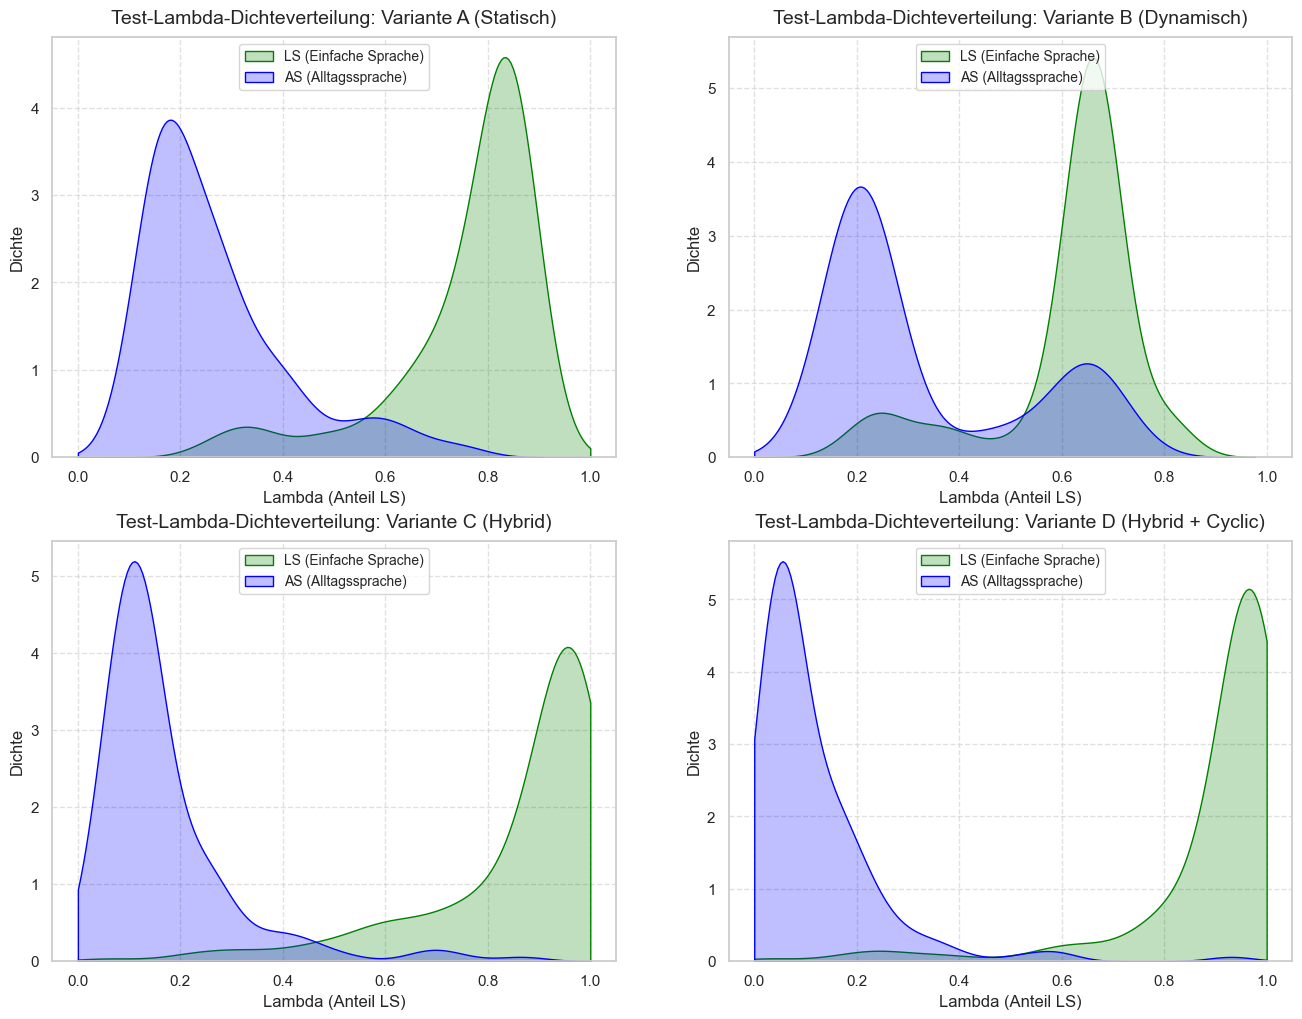

In [5]:
# 1.2. KDE-Plots (Dichteverteilungen) für die Klassifikation auf dem Test-Split
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(test_results.keys()):
    ls_p = test_results[model_name]["ls_preds"]
    as_p = test_results[model_name]["as_preds"]
    
    sns.kdeplot(ls_p, fill=True, color="green", label="LS (Einfache Sprache)", ax=axes[i], clip=(0.0, 1.0))
    sns.kdeplot(as_p, fill=True, color="blue", label="AS (Alltagssprache)", ax=axes[i], clip=(0.0, 1.0))
    
    if train_targets is not None:
        sns.kdeplot(train_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
    
    axes[i].set_title(f"Test-Lambda-Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren auf dem Test-Split (Reine Sätze) vs. Trainings-Target-Verteilung", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_test_distribution_with_targets.png", dpi=300)
plt.show()


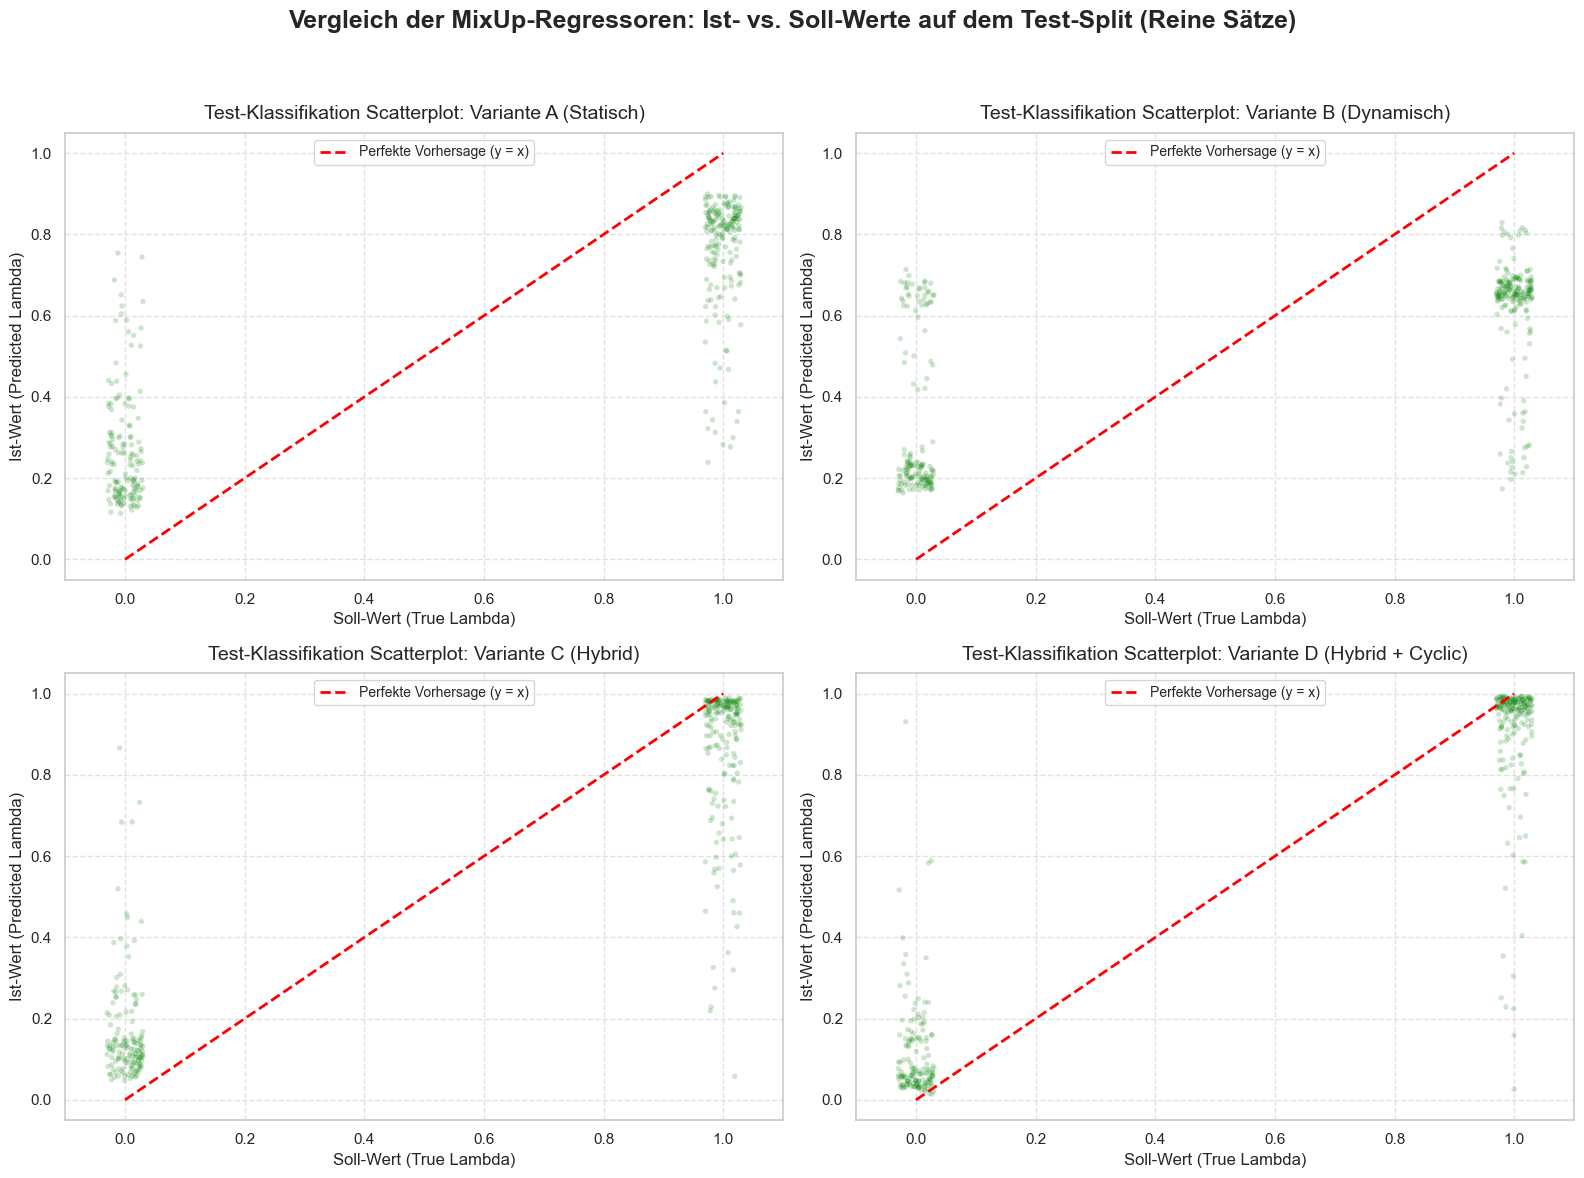

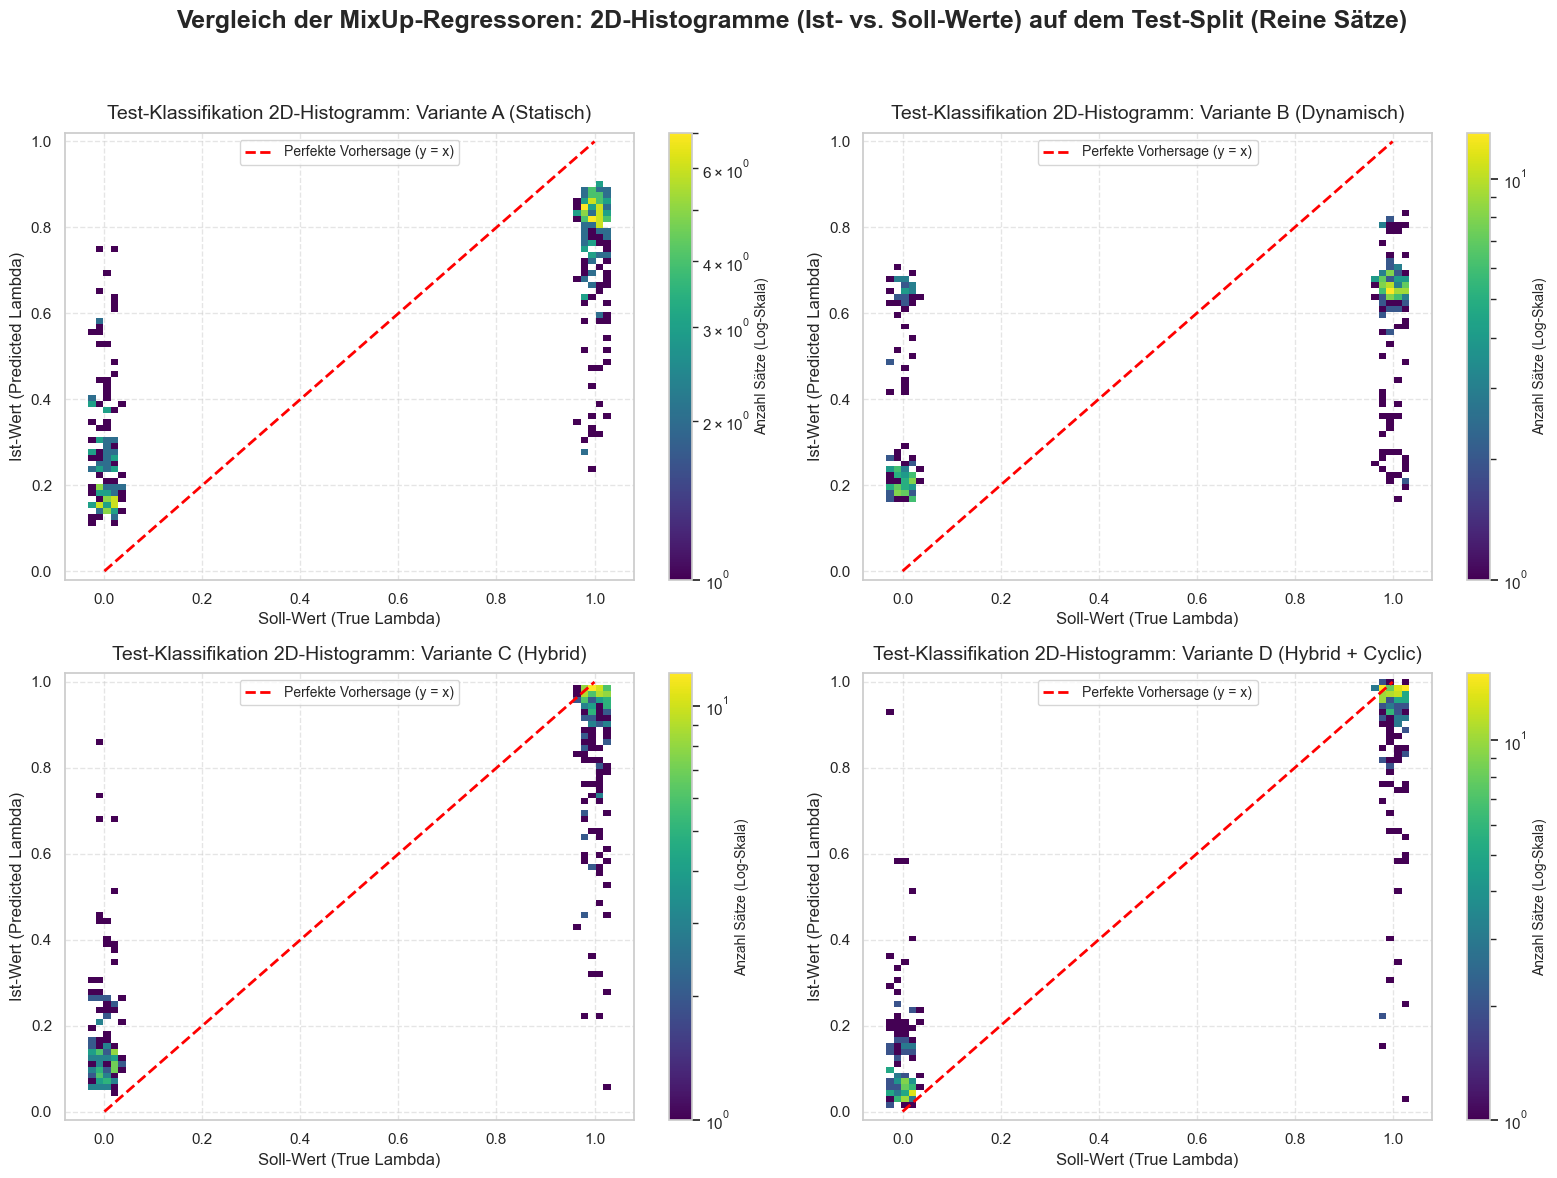

In [ ]:
# 1.2.5. Scatterplots (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Test-Split
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(test_results.keys()):
    ls_p = test_results[model_name]["ls_preds"]
    as_p = test_results[model_name]["as_preds"]
    
    # Wahre Targets: 1.0 für LS, 0.0 für AS
    true_ls = np.ones(len(ls_p))
    true_as = np.zeros(len(as_p))
    
    all_preds = np.concatenate([as_p, ls_p])
    all_targets = np.concatenate([true_as, true_ls])
    
    # Jitter hinzufügen für bessere Sichtbarkeit bei überlappenden Punkten
    jitter = np.random.uniform(-0.03, 0.03, len(all_targets))
    
    # Scatter plot
    axes[i].scatter(all_targets + jitter, all_preds, alpha=0.2, color="green", edgecolors='none', s=15)
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"Test-Klassifikation Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Test-Split (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_test_classification_scatterplot.png", dpi=300)
plt.show()

# 1.2.6. 2D-Histogramme (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Test-Split
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(test_results.keys()):
    ls_p = test_results[model_name]["ls_preds"]
    as_p = test_results[model_name]["as_preds"]
    
    # Wahre Targets: 1.0 für LS, 0.0 für AS
    true_ls = np.ones(len(ls_p))
    true_as = np.zeros(len(as_p))
    
    all_preds = np.concatenate([as_p, ls_p])
    all_targets = np.concatenate([true_as, true_ls])
    
    # Jitter für bessere Sichtbarkeit der Dichteverteilung auf der X-Achse
    jitter = np.random.uniform(-0.03, 0.03, len(all_targets))
    
    counts, xedges, yedges, im = axes[i].hist2d(
        all_targets + jitter, all_preds, bins=75, range=[[-0.08, 1.08], [-0.02, 1.02]],
        cmap="viridis", norm=mcolors.LogNorm(), cmin=1
    )
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"Test-Klassifikation 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.08, 1.08)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    
    cbar = fig.colorbar(im, ax=axes[i])
    cbar.set_label("Anzahl Sätze (Log-Skala)", fontsize=10)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Test-Split (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_test_classification_hist2d.png", dpi=300)
plt.show()


In [ ]:
# 1.3. Regressionsevaluation auf dem Test-Split (Mixup / Shuffled)
test_regression_dataset = TestMixupDataset(test_df, vocab, nlp, max_seq_len=150, mixtures_per_pair=10, seed=99)
test_regression_loader = DataLoader(test_regression_dataset, batch_size=64, shuffle=False)

test_reg_rows = []
test_reg_preds = {}

for model_name, model in models.items():
    if model is None:
        continue
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_regression_loader:
            batch_x = batch_x.to(DEVICE)
            preds = model(batch_x).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())
            
    test_reg_preds[model_name] = {"preds": all_preds, "targets": all_targets}
    
    mse = mean_squared_error(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    
    test_reg_rows.append({
        "Modell": model_name,
        "Test MSE (Regression)": f"{mse:.4f}",
        "Test MAE (Regression)": f"{mae:.4f}"
    })
    
df_test_reg_metrics = pd.DataFrame(test_reg_rows)
print("Regressionsergebnisse auf dem Test-Split (Mixup):")
display.display(df_test_reg_metrics)


Regressionsergebnisse auf dem Test-Split (Mixup):


,Modell,Test MSE (Regression),Test MAE (Regression)
0,Variante A (Statisch),0.0383,0.1557
1,Variante B (Dynamisch),0.0758,0.2264
2,Variante C (Hybrid),0.0267,0.1158
3,Variante D (Hybrid + Cyclic),0.0198,0.0889


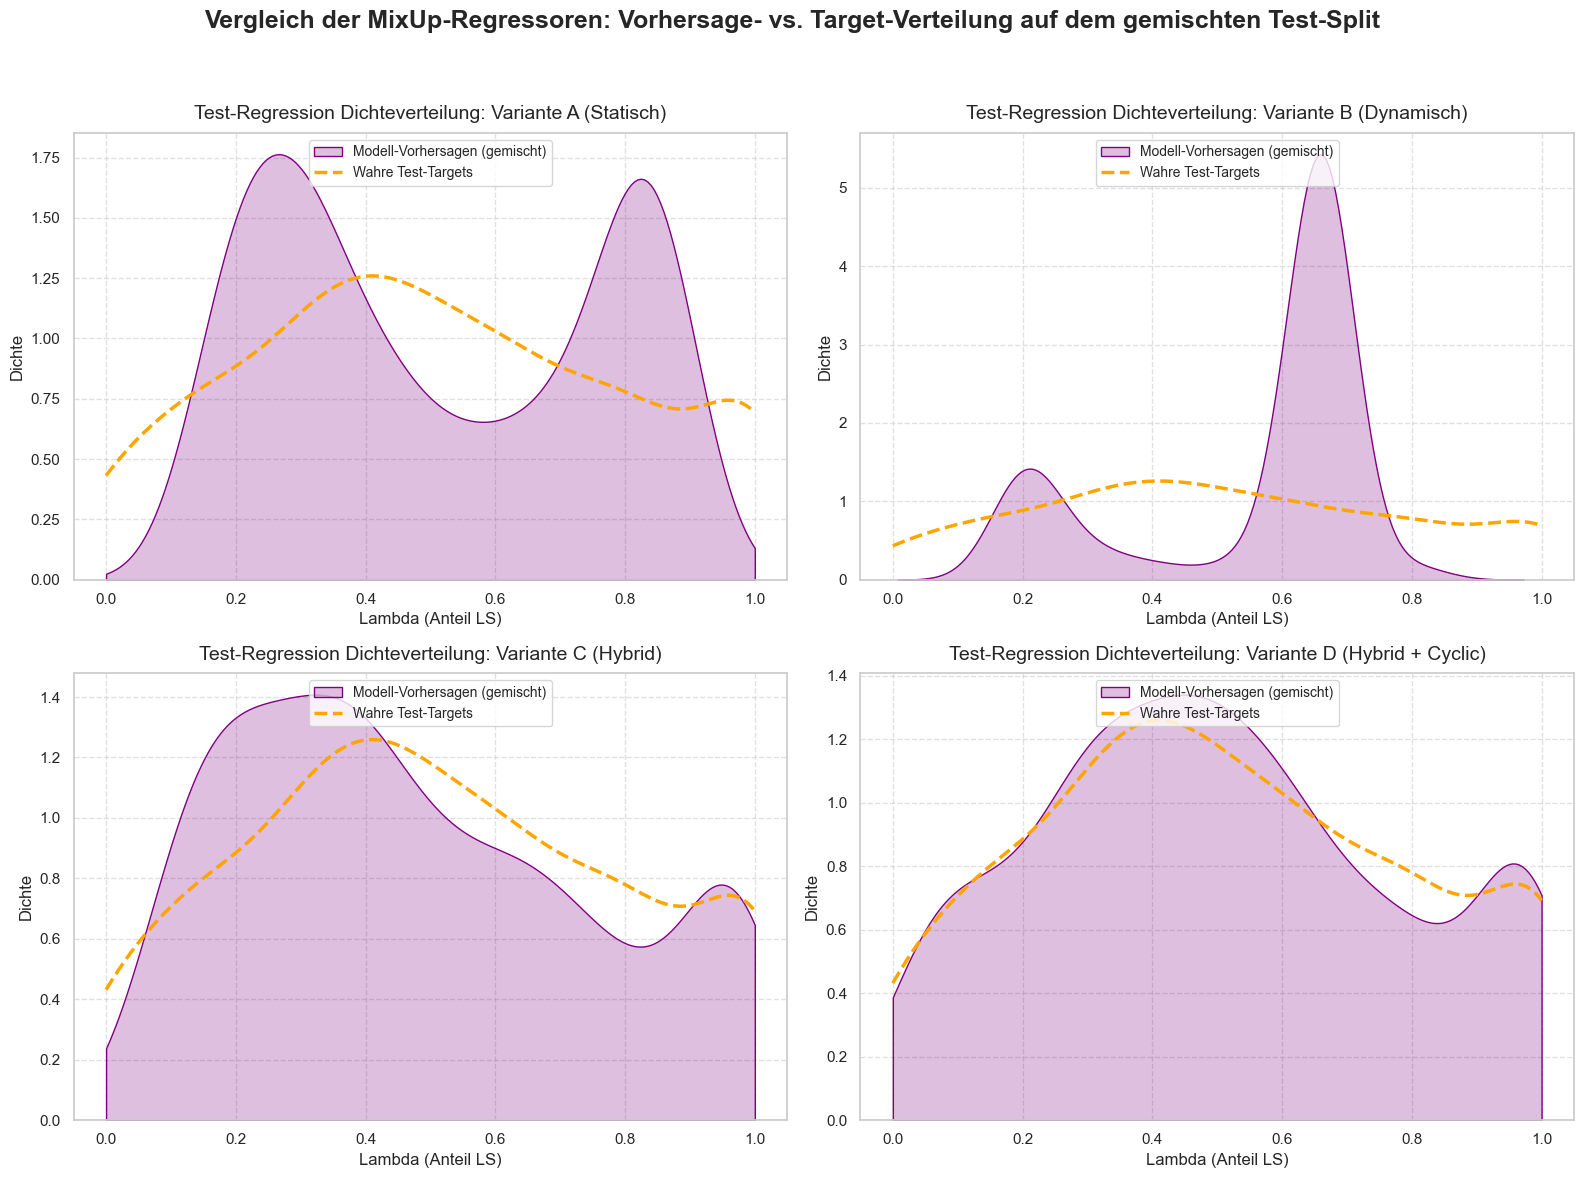

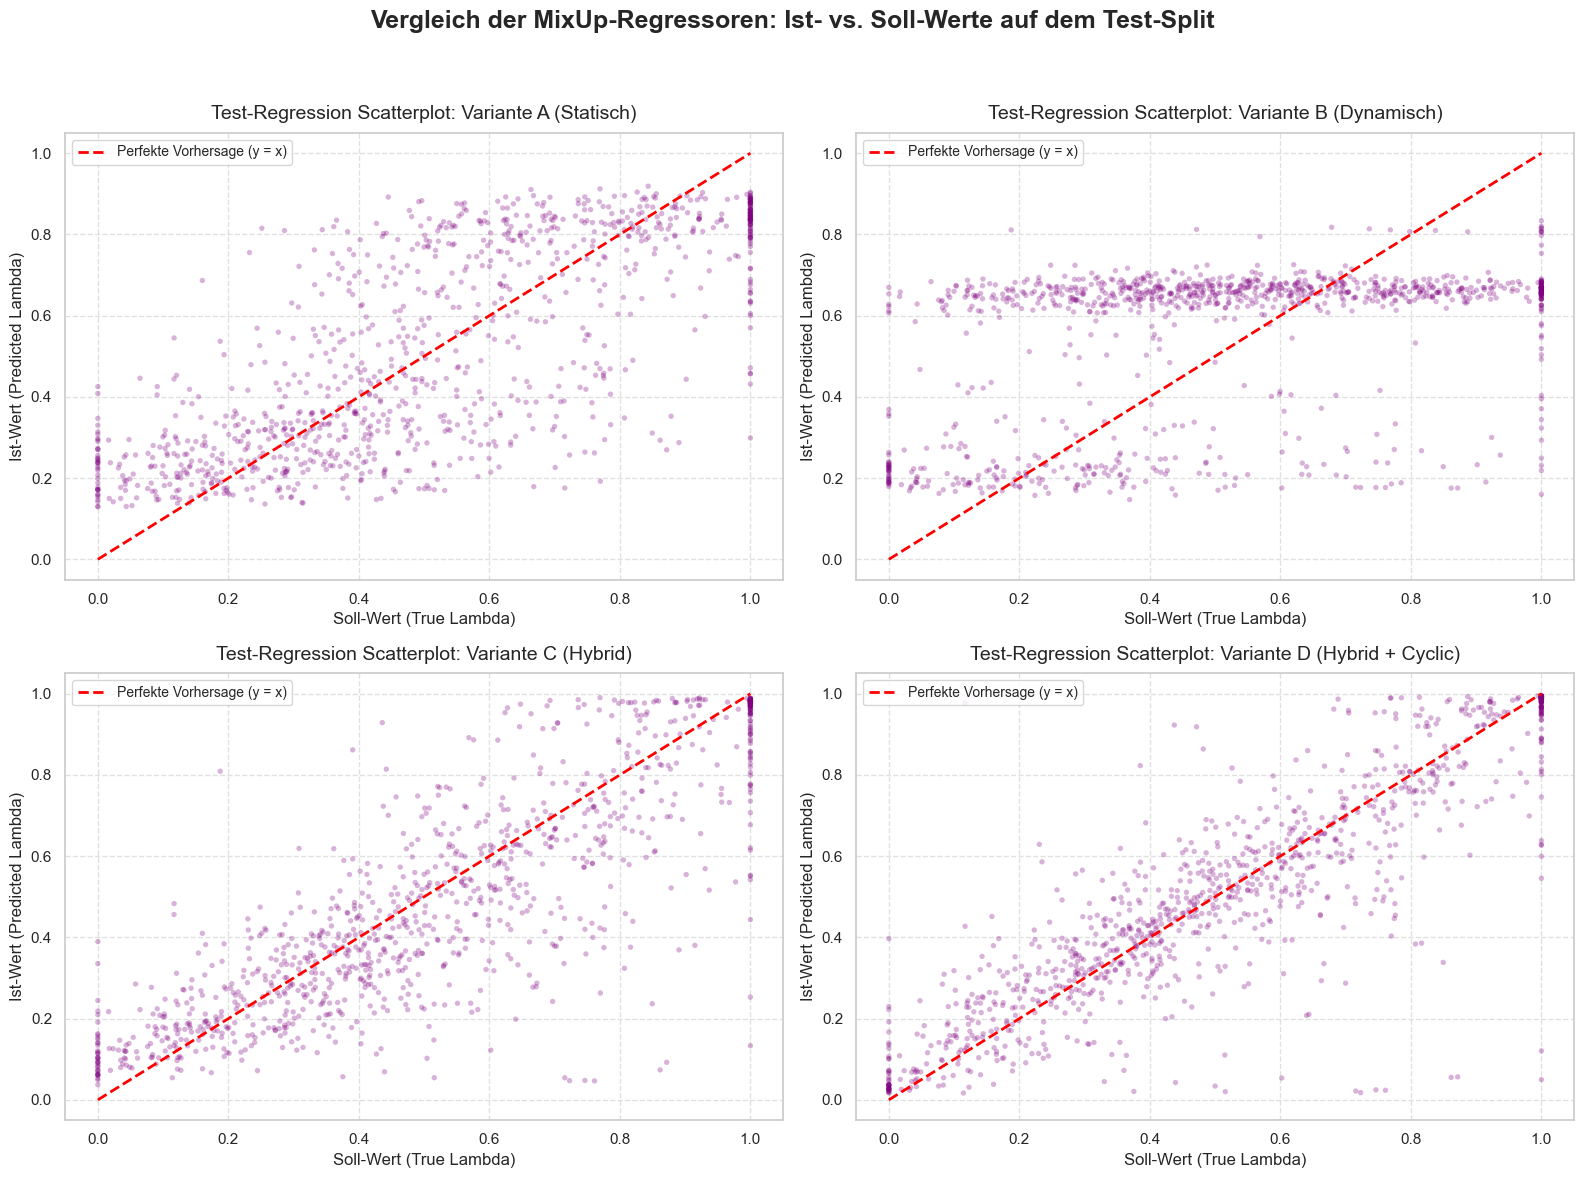

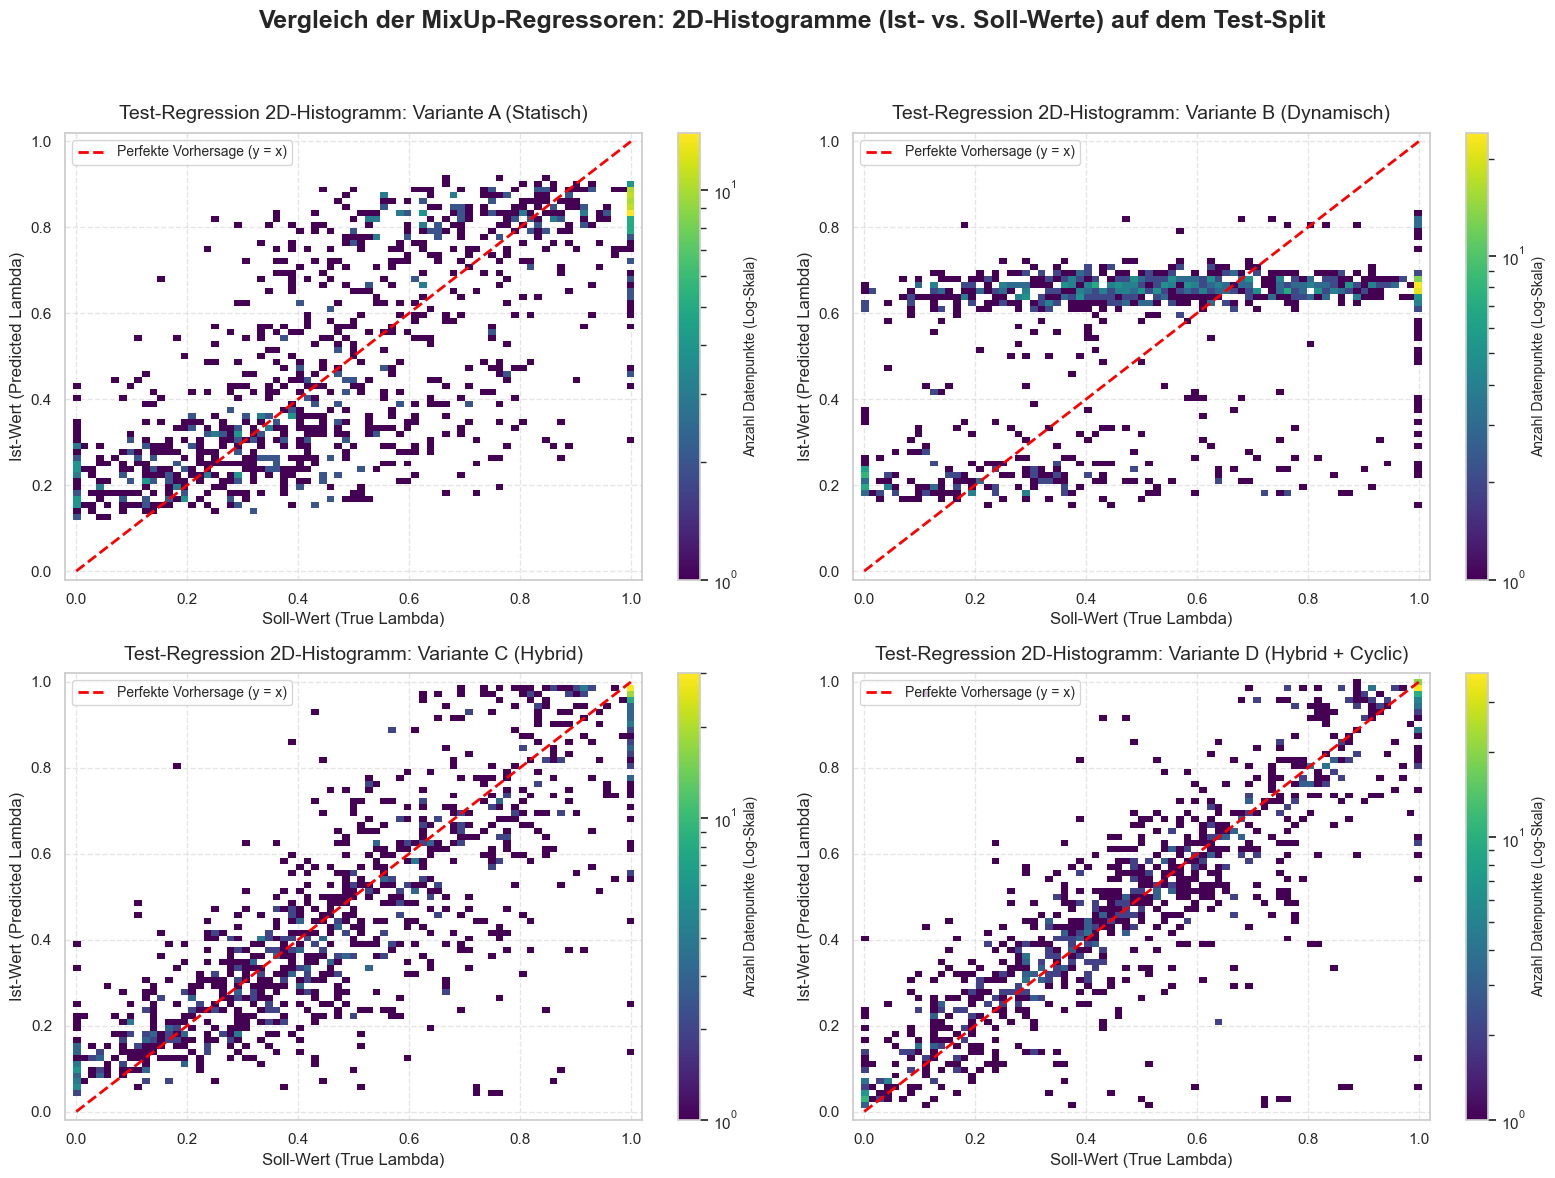

In [ ]:
# 1.4. Visualisierung der Regression auf dem Test-Split (KDE-Dichte, Scatterplots und 2D-Histogramme)

# 1.4.1. KDE-Plot der Vorhersagen (gemischt) vs. True Targets
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(test_reg_preds.keys()):
    all_preds = test_reg_preds[model_name]["preds"]
    all_targets = test_reg_preds[model_name]["targets"]
    
    sns.kdeplot(all_preds, fill=True, color="purple", label="Modell-Vorhersagen (gemischt)", ax=axes[i], clip=(0.0, 1.0))
    sns.kdeplot(all_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Wahre Test-Targets", ax=axes[i], clip=(0.0, 1.0))
    
    axes[i].set_title(f"Test-Regression Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Vorhersage- vs. Target-Verteilung auf dem gemischten Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_test_regression_kde.png", dpi=300)
plt.show()

# 1.4.2. Scatterplots Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(test_reg_preds.keys()):
    all_preds = test_reg_preds[model_name]["preds"]
    all_targets = test_reg_preds[model_name]["targets"]
    
    axes[i].scatter(all_targets, all_preds, alpha=0.3, color="purple", edgecolors='none', s=15)
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"Test-Regression Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_test_regression_scatterplot.png", dpi=300)
plt.show()

# 1.4.3. 2D-Histogramme Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(test_reg_preds.keys()):
    all_preds = test_reg_preds[model_name]["preds"]
    all_targets = test_reg_preds[model_name]["targets"]
    
    counts, xedges, yedges, im = axes[i].hist2d(
        all_targets, all_preds, bins=75, range=[[-0.02, 1.02], [-0.02, 1.02]],
        cmap="viridis", norm=mcolors.LogNorm(), cmin=1
    )
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"Test-Regression 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.02, 1.02)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    
    cbar = fig.colorbar(im, ax=axes[i])
    cbar.set_label("Anzahl Datenpunkte (Log-Skala)", fontsize=10)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_test_regression_hist2d.png", dpi=300)
plt.show()


# 2. Auswertung auf dem Lebenshilfe-Datensatz (Out-of-Domain)

In [ ]:
# 2.0. Lebenshilfe-Datensatz laden und DataFrame erstellen
LH_DATASET_PATH = "../../results/lebenshilfe_dataset_no_paragraphs.json"

with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)
print(f"Anzahl geladener Lebenshilfe Artikelpaare: {len(lh_data)}")
lh_df = pd.DataFrame(lh_data)


Anzahl geladener Lebenshilfe Artikelpaare: 49


In [ ]:
# 2.1. Binäre Klassifikationsevaluation auf dem Lebenshilfe-Set (LS = 1.0, AS = 0.0)
lh_results = {}
for model_name, model in models.items():
    if model is None:
        continue
    lh_results[model_name] = {"ls_preds": [], "as_preds": []}
    
    for _, row in tqdm(lh_df.iterrows(), total=len(lh_df), desc=f"LH-Vorhersagen für {model_name}"):
        ls_text = str(row.get("ls_text", ""))
        as_text = str(row.get("as_text", ""))
        
        # LS (Einfache Sprache)
        ls_seqs = text_to_sequences(ls_text, vocab)
        if ls_seqs:
            tensors = torch.tensor(ls_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                lh_results[model_name]["ls_preds"].extend(preds)

        # AS (Alltagssprache)
        as_seqs = text_to_sequences(as_text, vocab)
        if as_seqs:
            tensors = torch.tensor(as_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                lh_results[model_name]["as_preds"].extend(preds)

# Metriken berechnen
lh_table_rows = []
for model_name in lh_results.keys():
    ls_p = lh_results[model_name]["ls_preds"]
    as_p = lh_results[model_name]["as_preds"]
    
    mean_ls = np.mean(ls_p)
    mean_as = np.mean(as_p)
    
    correct_ls = sum(1 for p in ls_p if p > 0.5)
    correct_as = sum(1 for p in as_p if p <= 0.5)
    
    acc = (correct_ls + correct_as) / (len(ls_p) + len(as_p))
    bacc_ls = correct_ls / len(ls_p)
    bacc_as = correct_as / len(as_p)
    bacc = (bacc_ls + bacc_as) / 2
    mae = (sum(1.0 - p for p in ls_p) + sum(p for p in as_p)) / (len(ls_p) + len(as_p))
    
    lh_table_rows.append({
        "Modell": model_name,
        "Ø Lambda (LS)": f"{mean_ls:.4f}",
        "Ø Lambda (AS)": f"{mean_as:.4f}",
        "Accuracy (Schwelle 0.5)": f"{acc*100:.2f}%",
        "Balanced Acc": f"{bacc*100:.2f}%",
        "MAE (Target 1/0)": f"{mae:.4f}"
    })
    
df_lh_metrics = pd.DataFrame(lh_table_rows)
print("Klassifikationsergebnisse auf dem Lebenshilfe-Datensatz (Reine Sätze):")
display.display(df_lh_metrics)


LH-Vorhersagen für Variante D (Hybrid + Cyclic): 100%|██████████| 49/49 [00:06<00:00,  7.64it/s]

Klassifikationsergebnisse auf dem Lebenshilfe-Datensatz (Reine Sätze):


,Modell,Ø Lambda (LS),Ø Lambda (AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,Variante A (Statisch),0.6533,0.1958,82.67%,85.75%,0.2888
1,Variante B (Dynamisch),0.6241,0.2766,87.42%,86.32%,0.3378
2,Variante C (Hybrid),0.6397,0.1236,82.03%,85.10%,0.2695
3,Variante D (Hybrid + Cyclic),0.7427,0.0987,90.12%,91.47%,0.1964


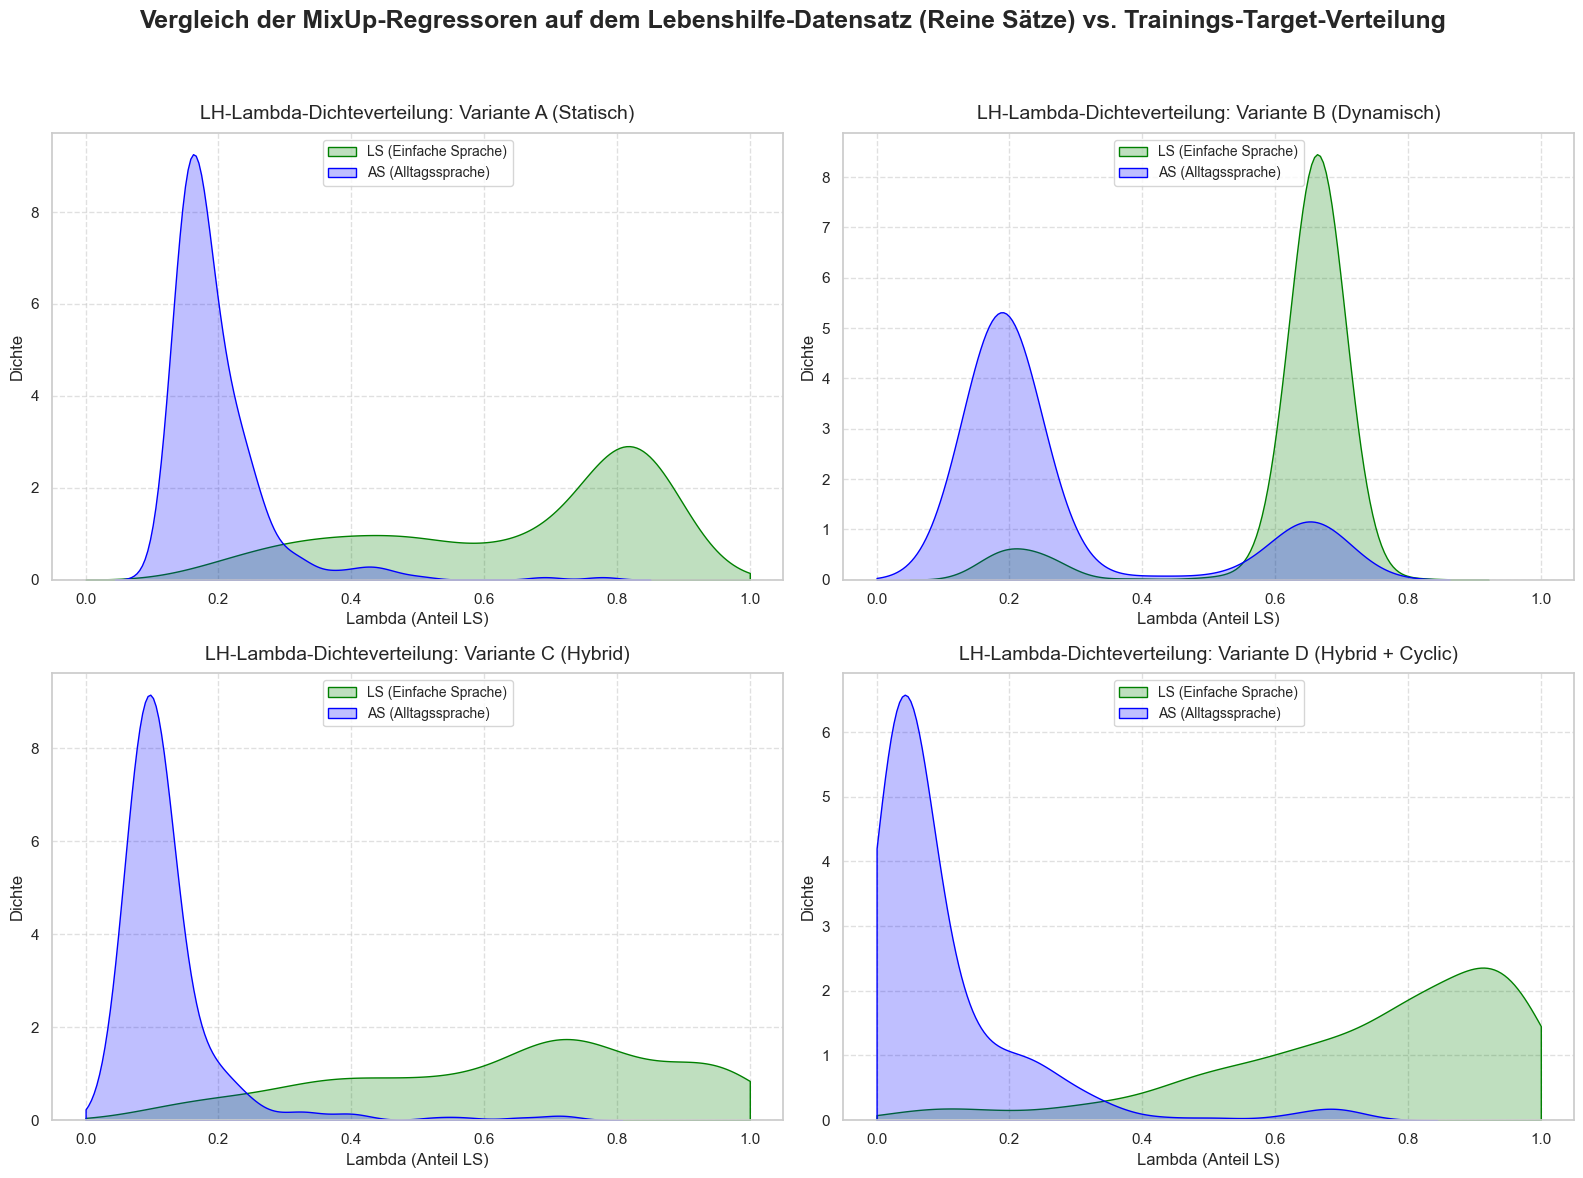

In [ ]:
# 2.2. KDE-Plots (Dichteverteilungen) für die Klassifikation auf dem Lebenshilfe-Set
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(lh_results.keys()):
    ls_p = lh_results[model_name]["ls_preds"]
    as_p = lh_results[model_name]["as_preds"]
    
    sns.kdeplot(ls_p, fill=True, color="green", label="LS (Einfache Sprache)", ax=axes[i], clip=(0.0, 1.0))
    sns.kdeplot(as_p, fill=True, color="blue", label="AS (Alltagssprache)", ax=axes[i], clip=(0.0, 1.0))
    
    if train_targets is not None:
        sns.kdeplot(train_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
    
    axes[i].set_title(f"LH-Lambda-Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren auf dem Lebenshilfe-Datensatz (Reine Sätze) vs. Trainings-Target-Verteilung", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_distribution_with_targets.png", dpi=300)
plt.show()


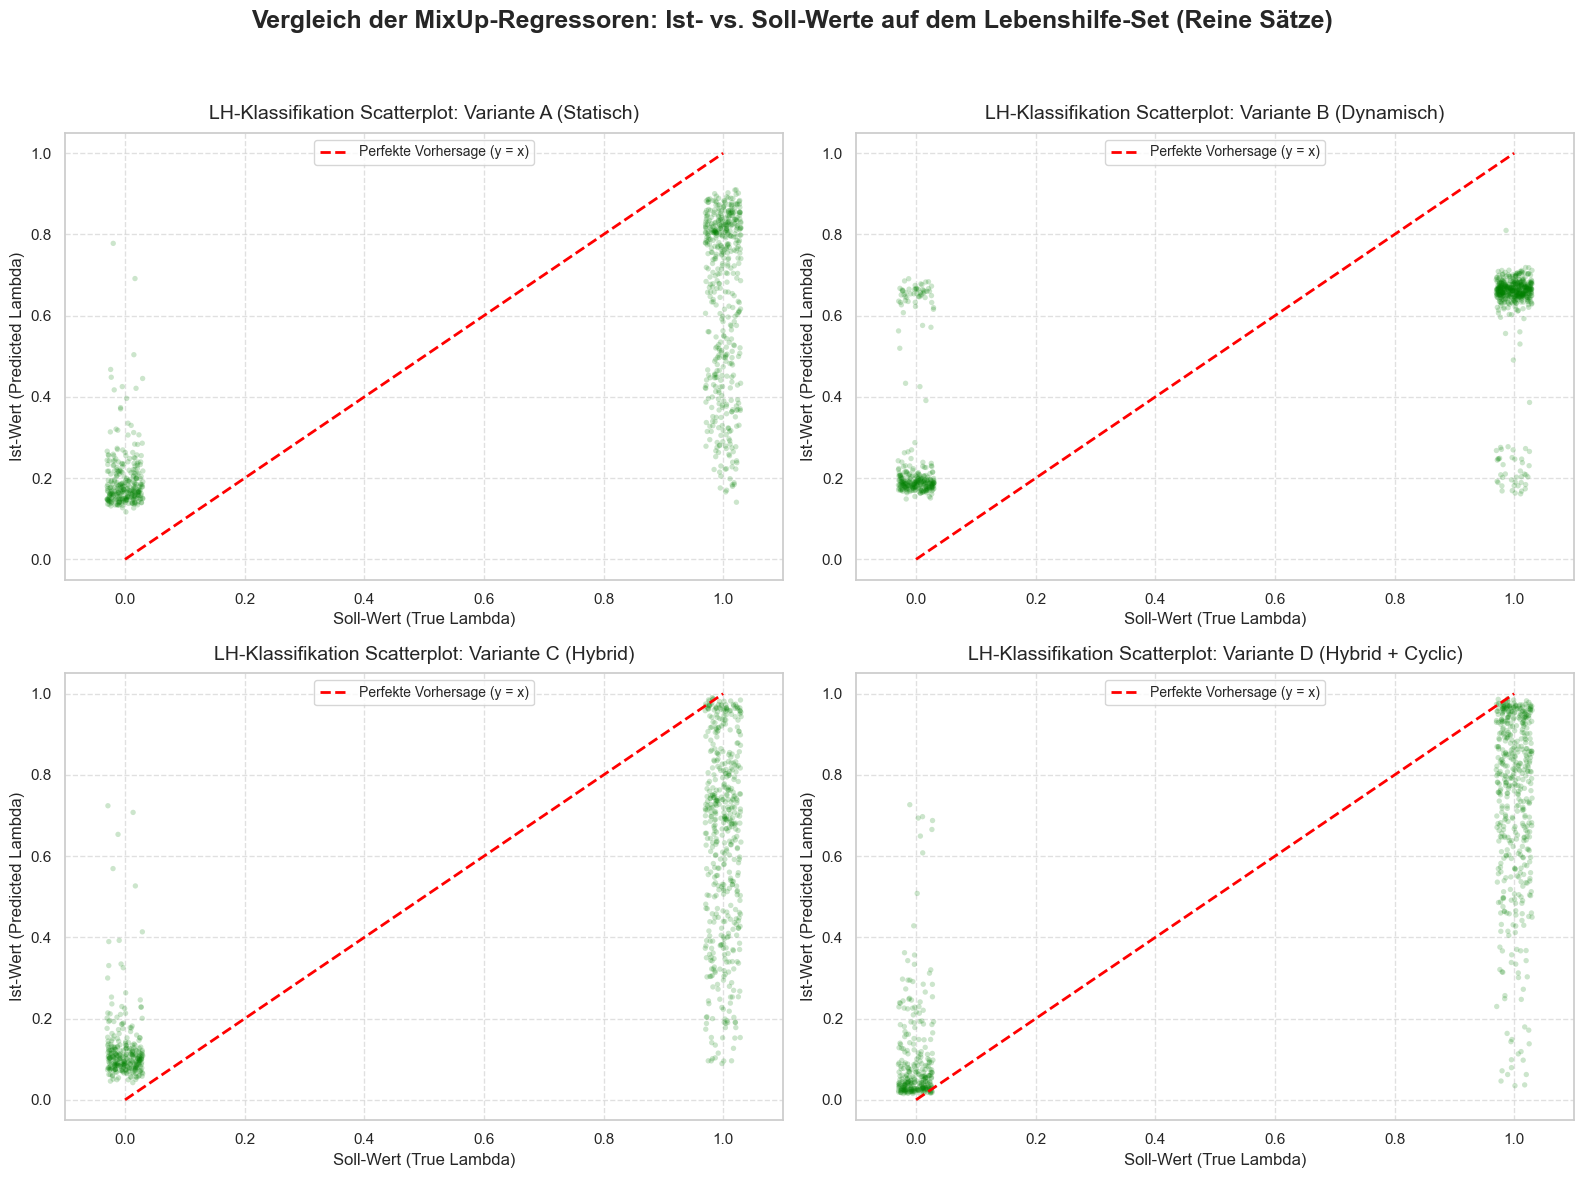

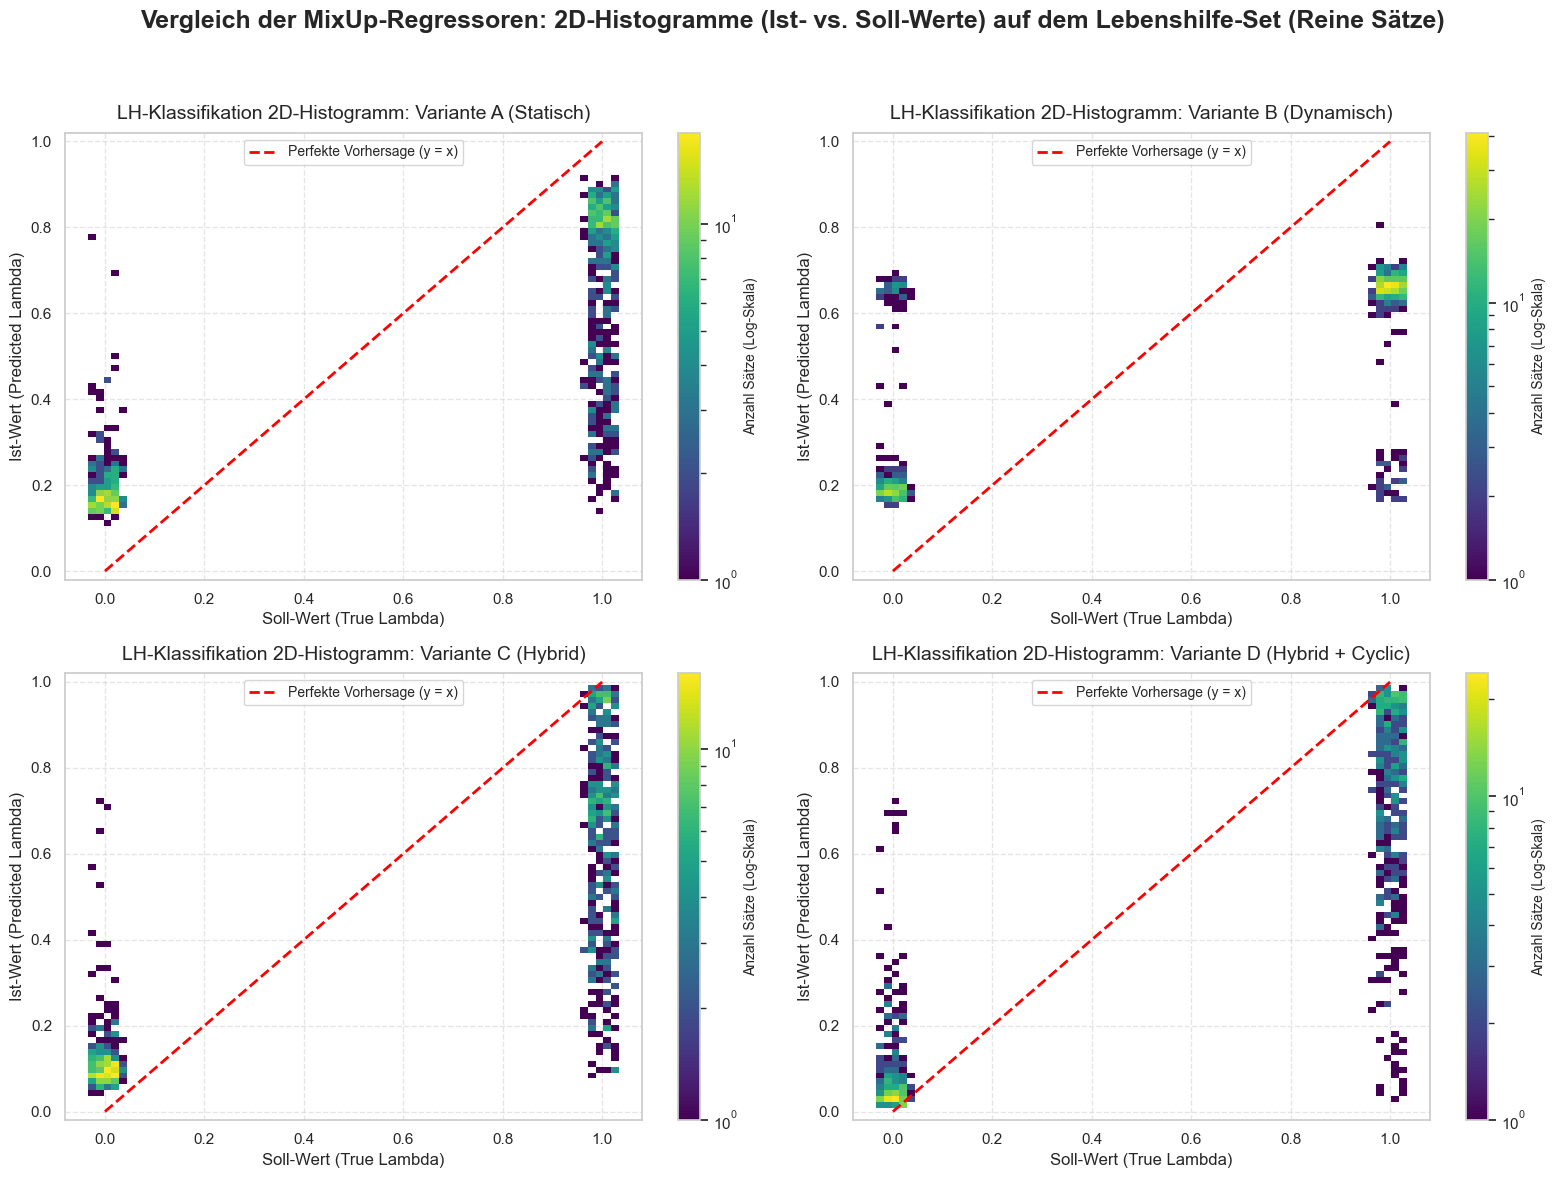

In [ ]:
# 2.2.5. Scatterplots (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Lebenshilfe-Set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(lh_results.keys()):
    ls_p = lh_results[model_name]["ls_preds"]
    as_p = lh_results[model_name]["as_preds"]
    
    # Wahre Targets: 1.0 für LS, 0.0 für AS
    true_ls = np.ones(len(ls_p))
    true_as = np.zeros(len(as_p))
    
    all_preds = np.concatenate([as_p, ls_p])
    all_targets = np.concatenate([true_as, true_ls])
    
    # Jitter für Punkteüberlagerung
    jitter = np.random.uniform(-0.03, 0.03, len(all_targets))
    
    # Scatter plot
    axes[i].scatter(all_targets + jitter, all_preds, alpha=0.2, color="green", edgecolors='none', s=15)
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"LH-Klassifikation Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Lebenshilfe-Set (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_lh_classification_scatterplot.png", dpi=300)
plt.show()

# 2.2.6. 2D-Histogramme (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Lebenshilfe-Set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(lh_results.keys()):
    ls_p = lh_results[model_name]["ls_preds"]
    as_p = lh_results[model_name]["as_preds"]
    
    # Wahre Targets: 1.0 für LS, 0.0 für AS
    true_ls = np.ones(len(ls_p))
    true_as = np.zeros(len(as_p))
    
    all_preds = np.concatenate([as_p, ls_p])
    all_targets = np.concatenate([true_as, true_ls])
    
    # Jitter für bessere Sichtbarkeit der Dichteverteilung auf der X-Achse
    jitter = np.random.uniform(-0.03, 0.03, len(all_targets))
    
    counts, xedges, yedges, im = axes[i].hist2d(
        all_targets + jitter, all_preds, bins=75, range=[[-0.08, 1.08], [-0.02, 1.02]],
        cmap="viridis", norm=mcolors.LogNorm(), cmin=1
    )
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"LH-Klassifikation 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.08, 1.08)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    
    cbar = fig.colorbar(im, ax=axes[i])
    cbar.set_label("Anzahl Sätze (Log-Skala)", fontsize=10)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Lebenshilfe-Set (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_lh_classification_hist2d.png", dpi=300)
plt.show()


In [ ]:
# 2.3. Regressionsevaluation auf dem Lebenshilfe-Set (Mixup / Shuffled)
lh_regression_dataset = TestMixupDataset(lh_df, vocab, nlp, max_seq_len=150, mixtures_per_pair=10, seed=99)
lh_regression_loader = DataLoader(lh_regression_dataset, batch_size=64, shuffle=False)

lh_reg_rows = []
lh_reg_preds = {}

for model_name, model in models.items():
    if model is None:
        continue
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in lh_regression_loader:
            batch_x = batch_x.to(DEVICE)
            preds = model(batch_x).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())
            
    lh_reg_preds[model_name] = {"preds": all_preds, "targets": all_targets}
    
    mse = mean_squared_error(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    
    lh_reg_rows.append({
        "Modell": model_name,
        "LH MSE (Regression)": f"{mse:.4f}",
        "LH MAE (Regression)": f"{mae:.4f}"
    })
    
df_lh_reg_metrics = pd.DataFrame(lh_reg_rows)
print("Regressionsergebnisse auf dem Lebenshilfe-Datensatz (Mixup):")
display.display(df_lh_reg_metrics)


Regressionsergebnisse auf dem Lebenshilfe-Datensatz (Mixup):


,Modell,LH MSE (Regression),LH MAE (Regression)
0,Variante A (Statisch),0.0725,0.2111
1,Variante B (Dynamisch),0.0766,0.2212
2,Variante C (Hybrid),0.0840,0.2279
3,Variante D (Hybrid + Cyclic),0.0600,0.1808


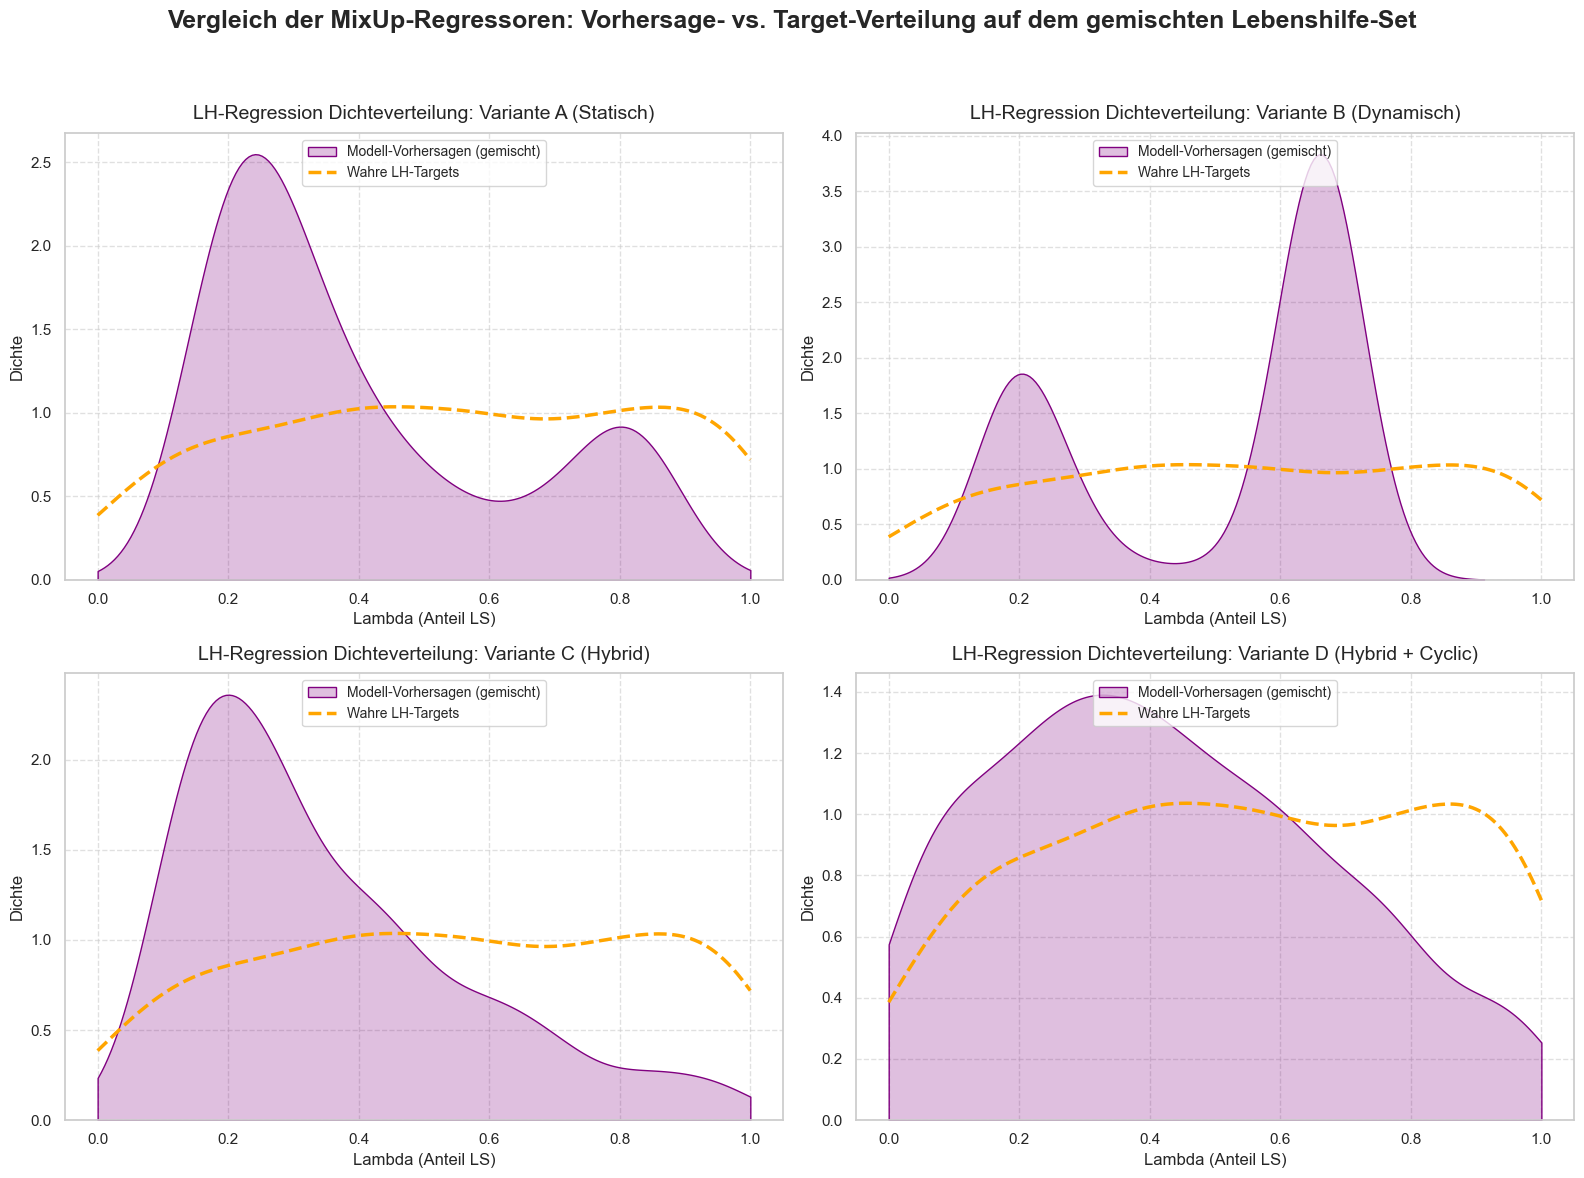

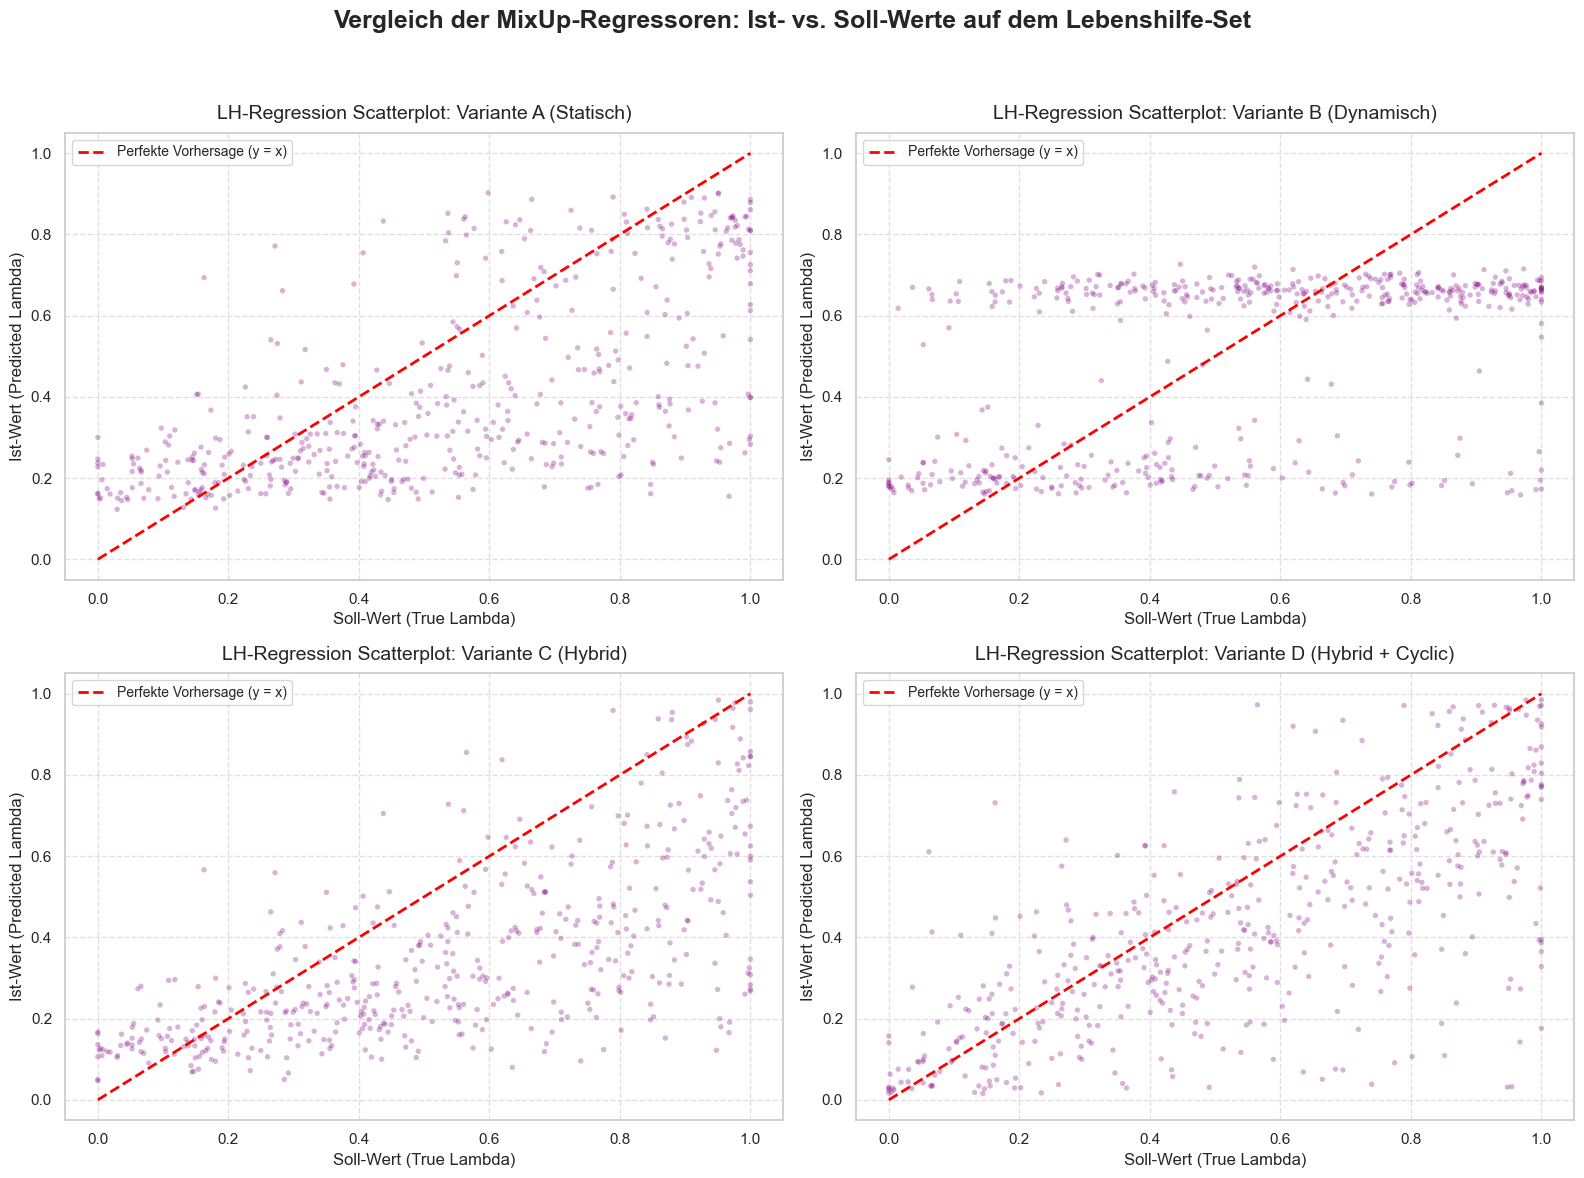

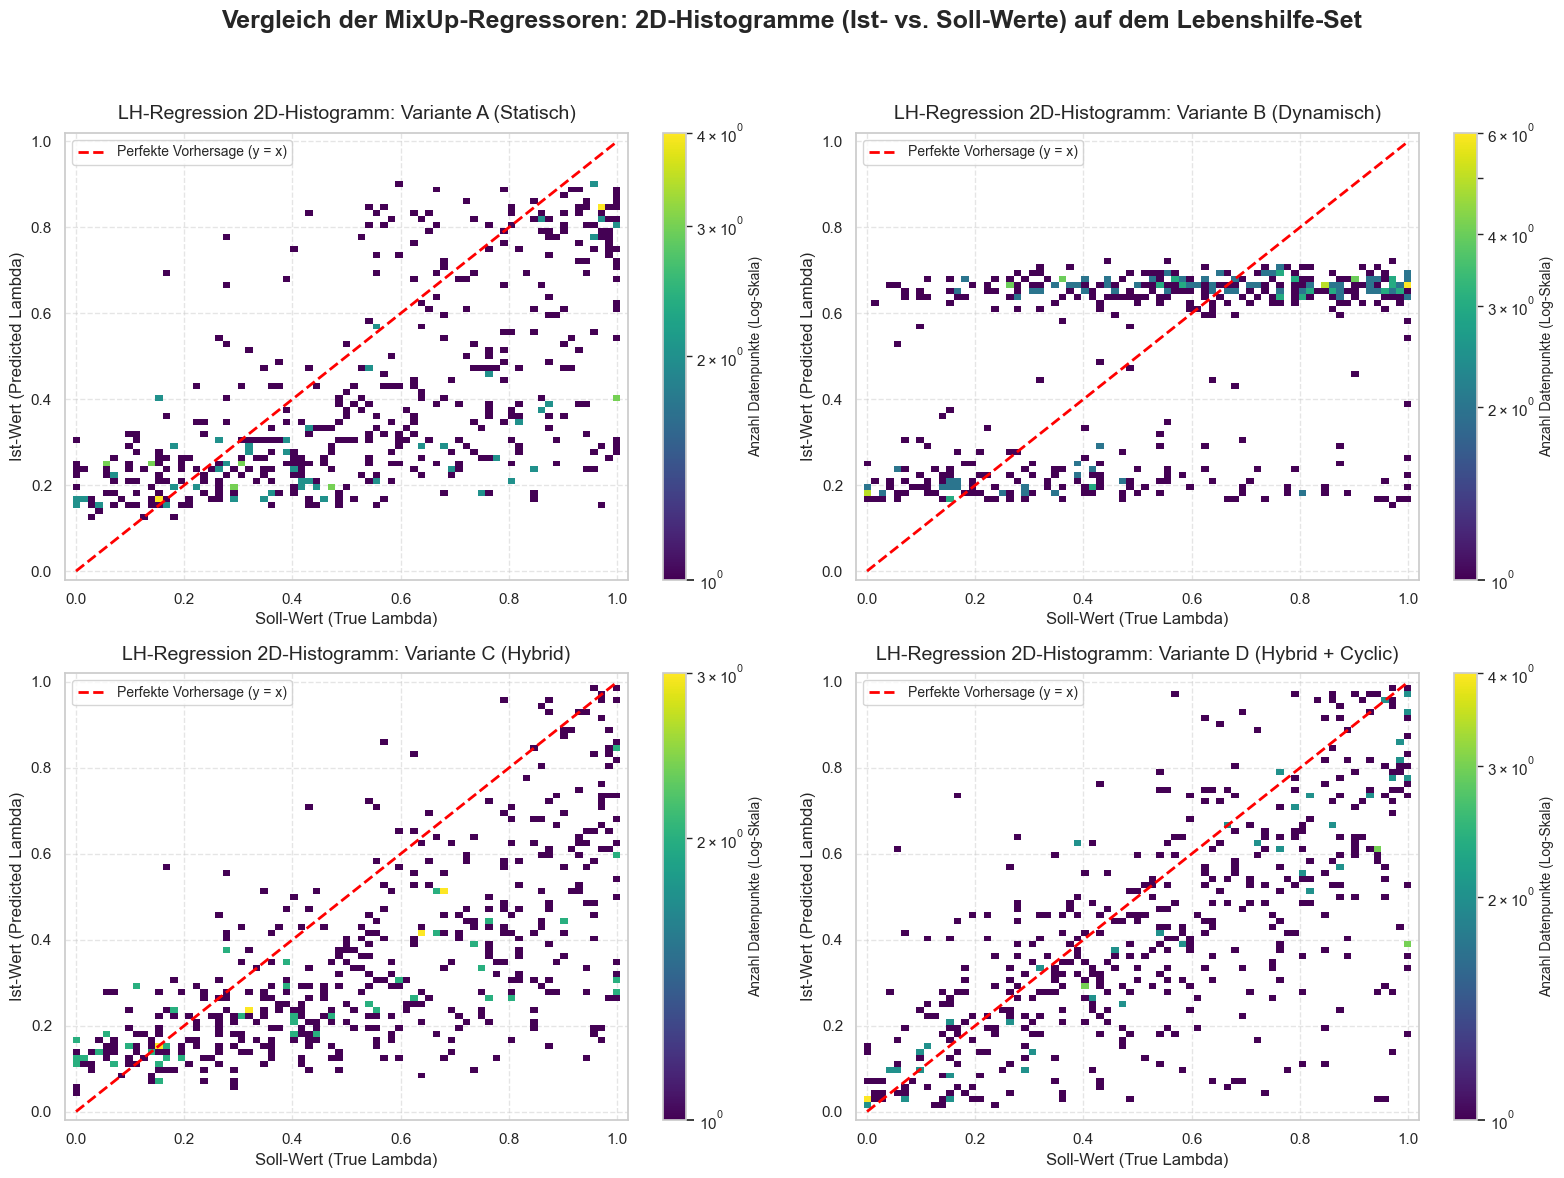

In [ ]:
# 2.4. Visualisierung der Regression auf dem Lebenshilfe-Set (KDE-Dichte, Scatterplots und 2D-Histogramme)

# 2.4.1. KDE-Plot der Vorhersagen (gemischt) vs. True Targets
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(lh_reg_preds.keys()):
    all_preds = lh_reg_preds[model_name]["preds"]
    all_targets = lh_reg_preds[model_name]["targets"]
    
    sns.kdeplot(all_preds, fill=True, color="purple", label="Modell-Vorhersagen (gemischt)", ax=axes[i], clip=(0.0, 1.0))
    sns.kdeplot(all_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Wahre LH-Targets", ax=axes[i], clip=(0.0, 1.0))
    
    axes[i].set_title(f"LH-Regression Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Vorhersage- vs. Target-Verteilung auf dem gemischten Lebenshilfe-Set", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_lh_regression_kde.png", dpi=300)
plt.show()

# 2.4.2. Scatterplots Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(lh_reg_preds.keys()):
    all_preds = lh_reg_preds[model_name]["preds"]
    all_targets = lh_reg_preds[model_name]["targets"]
    
    axes[i].scatter(all_targets, all_preds, alpha=0.3, color="purple", edgecolors='none', s=15)
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"LH-Regression Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Lebenshilfe-Set", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_lh_regression_scatterplot.png", dpi=300)
plt.show()

# 2.4.3. 2D-Histogramme Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(lh_reg_preds.keys()):
    all_preds = lh_reg_preds[model_name]["preds"]
    all_targets = lh_reg_preds[model_name]["targets"]
    
    counts, xedges, yedges, im = axes[i].hist2d(
        all_targets, all_preds, bins=75, range=[[-0.02, 1.02], [-0.02, 1.02]],
        cmap="viridis", norm=mcolors.LogNorm(), cmin=1
    )
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"LH-Regression 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.02, 1.02)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    
    cbar = fig.colorbar(im, ax=axes[i])
    cbar.set_label("Anzahl Datenpunkte (Log-Skala)", fontsize=10)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Lebenshilfe-Set", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_lh_regression_hist2d.png", dpi=300)
plt.show()
